# Setup & Libraries

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
from flask import Flask, request, jsonify
import numpy as np
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# Data Loading

In [4]:
df = pd.read_csv("heart.csv", sep=None, engine="python")


# Data Overview

In [5]:
df.head(10)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
df.shape


(918, 12)

In [9]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

# Data Quality Checks

In [10]:
print('Missing values in the dataset : ',df.isna().sum().sum())

Missing values in the dataset :  0


In [11]:
print('Duplicate values in the dataset : ',df.duplicated().sum())

Duplicate values in the dataset :  0


# Exploratory Data Analysis

## Data Visualization

In [12]:
print(df.columns)


Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')


/tmp/ipython-input-4256421828.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Disease', 'Disease'])


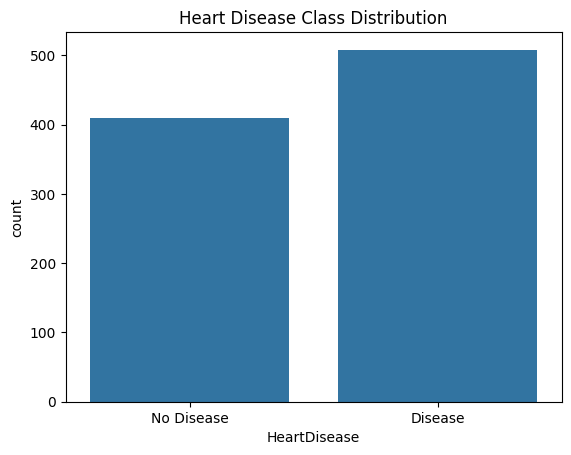

In [13]:
ax = sns.countplot(x='HeartDisease', data=df, order=[0,1])
ax.set_xticklabels(['No Disease', 'Disease'])
plt.title('Heart Disease Class Distribution')
plt.show()

In [14]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')


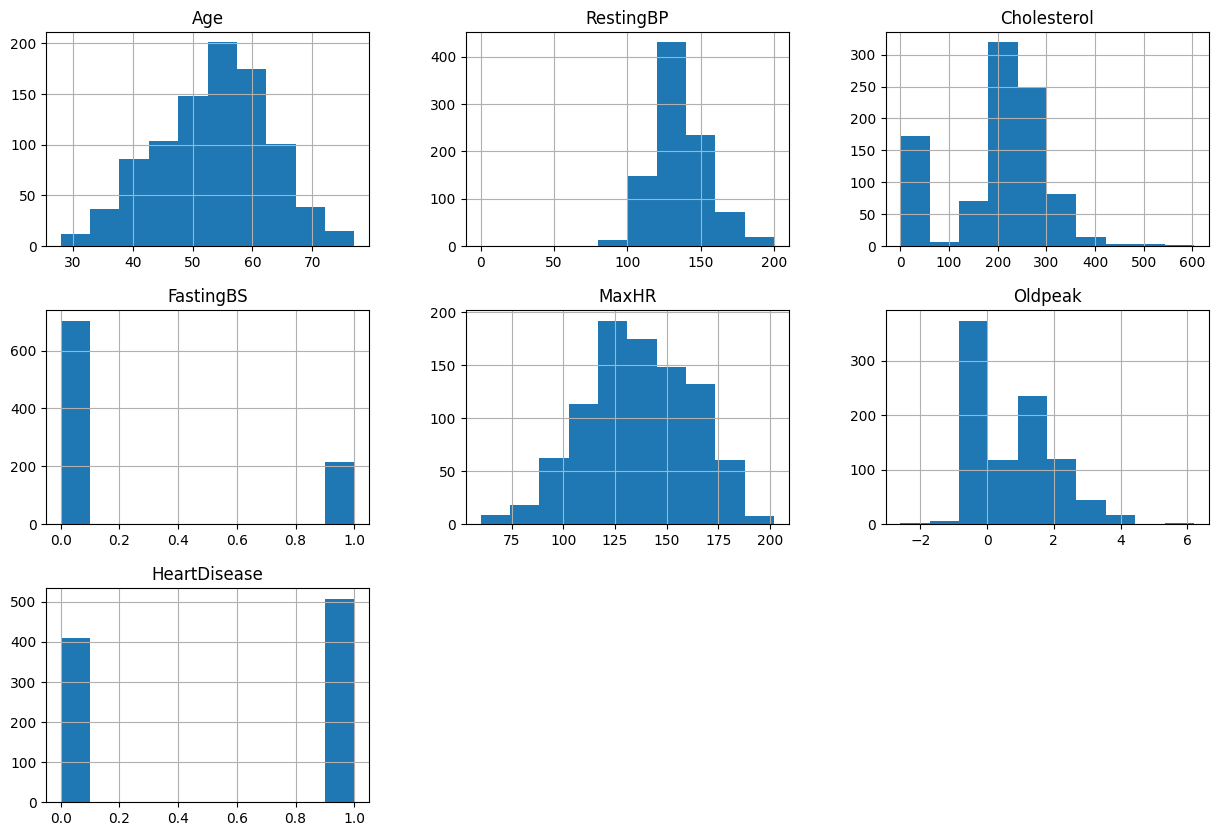

In [15]:
df[num_cols].hist(figsize=(15,10))
plt.show()

/tmp/ipython-input-3981471328.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Disease', 'Disease'])


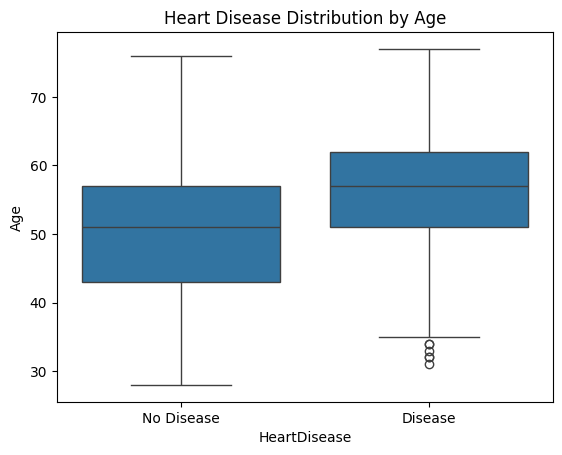

In [16]:
# Stroke vs age
ax = sns.boxplot(x='HeartDisease', y='Age', data=df, order=[0, 1])
ax.set_xticklabels(['No Disease', 'Disease'])
plt.title('Heart Disease Distribution by Age')
plt.show()

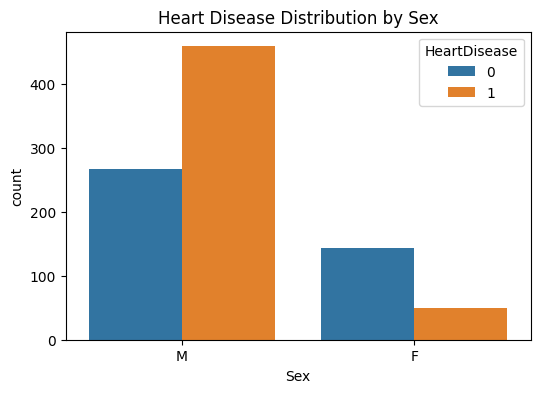

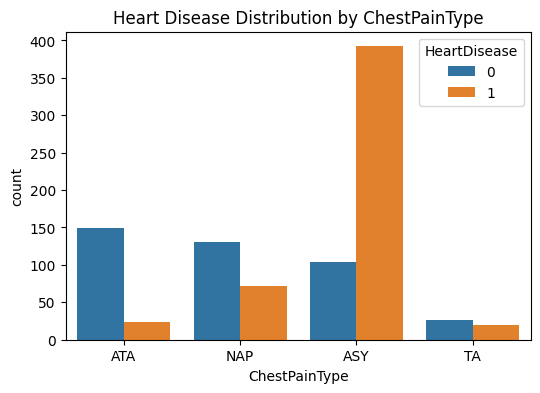

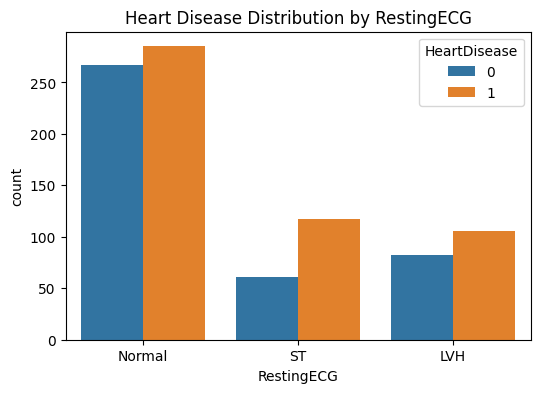

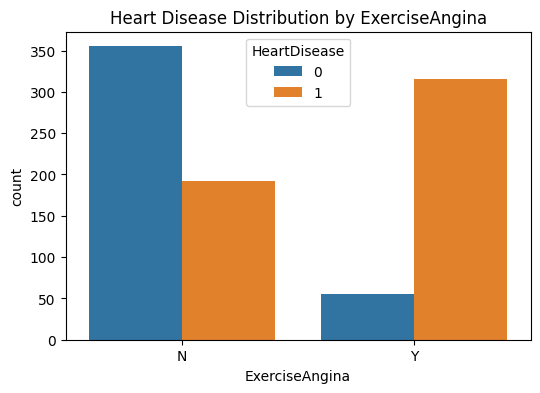

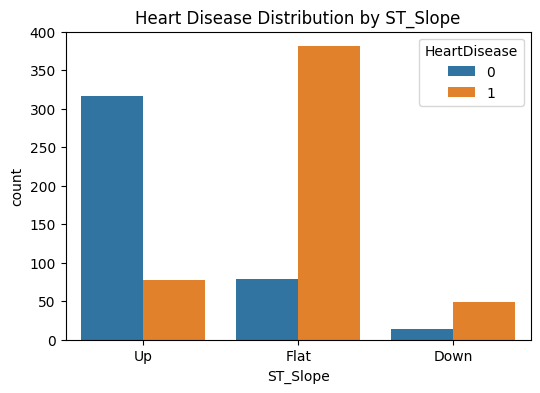

In [17]:
# Categorical Features vs Heart Disease

categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    ax = sns.countplot(x=col, hue='HeartDisease', data=df)
    plt.title(f'Heart Disease Distribution by {col}')
    plt.show()


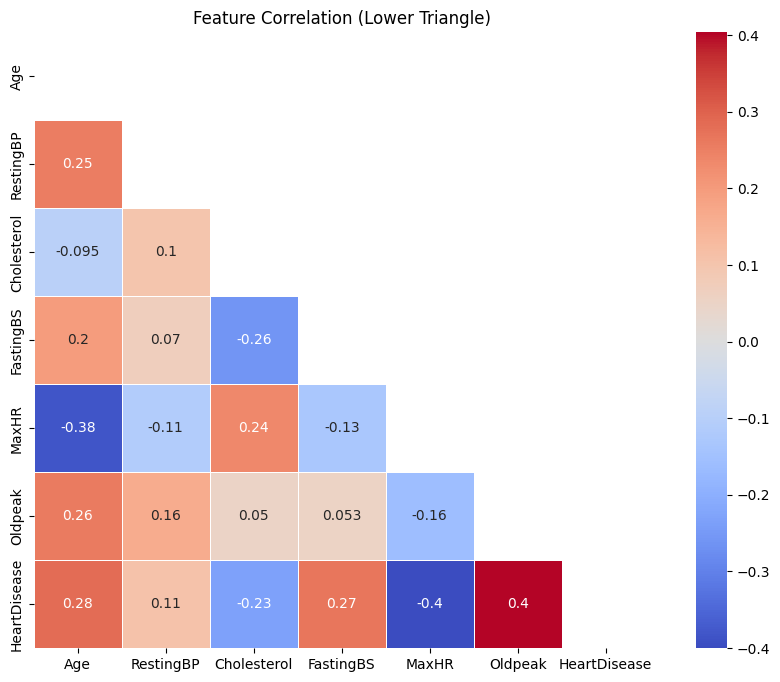

In [18]:
plt.figure(figsize=(12, 8))

# Calculate correlation matrix
corr = df[num_cols].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot heatmap with the mask applied
sns.heatmap(corr, annot=True, cmap="coolwarm", mask=mask, square=True, linewidths=0.5)

plt.title("Feature Correlation (Lower Triangle)")
plt.show()

# Train-Test Split


In [19]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

print(f'Train samples: {X_train_final.shape[0]}')
print(f'Validation samples: {X_val.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')


Train samples: 550
Validation samples: 184
Test samples: 184


# Preprocessing Pipeline: Scaling & Encoding


In [21]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [22]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [23]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [24]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Model Training & Evaluation

### Create Model Pipelines

In [25]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42)
}


In [26]:
pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

In [27]:
scoring = ['accuracy', 'precision', 'recall', 'f1']

for name, pipeline in pipelines.items():
    scores = cross_validate(pipeline, X, y, cv=5, scoring=scoring)
    print(f"Model: {name}")
    for metric in scoring:
        mean_score = scores[f'test_{metric}'].mean()
        print(f"  {metric}: {mean_score:.3f}")
    print()

Model: Decision Tree
  accuracy: 0.742
  precision: 0.798
  recall: 0.724
  f1: 0.753

Model: Logistic Regression
  accuracy: 0.829
  precision: 0.856
  recall: 0.840
  f1: 0.843

Model: Random Forest
  accuracy: 0.831
  precision: 0.852
  recall: 0.850
  f1: 0.846

Model: Gradient Boosting
  accuracy: 0.828
  precision: 0.857
  recall: 0.840
  f1: 0.843

Model: SVM
  accuracy: 0.832
  precision: 0.848
  recall: 0.860
  f1: 0.849

Model: KNN
  accuracy: 0.837
  precision: 0.858
  recall: 0.850
  f1: 0.850



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:03:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:03:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:03:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:03:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:03:05] WARNING: /w

Model: XGBoost
  accuracy: 0.810
  precision: 0.838
  recall: 0.829
  f1: 0.827

[LightGBM] [Info] Number of positive: 406, number of negative: 328
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 389
[LightGBM] [Info] Number of data points in the train set: 734, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.553134 -> initscore=0.213340
[LightGBM] [Info] Start training from score 0.213340
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [28]:
best_score = 0
best_metric = 'recall'
best_model_name = None

for name, pipeline in pipelines.items():
    scores = cross_validate(pipeline, X, y, cv=5, scoring=scoring)
    mean_score = scores[f'test_{best_metric}'].mean()
    print(f"{name} - Accuracy: {scores['test_accuracy'].mean():.3f}, Precision: {scores['test_precision'].mean():.3f}, Recall: {scores['test_recall'].mean():.3f}, F1: {scores['test_f1'].mean():.3f}")

    if mean_score > best_score:
        best_score = mean_score
        best_model_name = name

print(f"\nBest model based on {best_metric}: {best_model_name} ({best_score:.3f})")


Decision Tree - Accuracy: 0.742, Precision: 0.798, Recall: 0.724, F1: 0.753
Logistic Regression - Accuracy: 0.829, Precision: 0.856, Recall: 0.840, F1: 0.843
Random Forest - Accuracy: 0.831, Precision: 0.852, Recall: 0.850, F1: 0.846
Gradient Boosting - Accuracy: 0.828, Precision: 0.857, Recall: 0.840, F1: 0.843
SVM - Accuracy: 0.832, Precision: 0.848, Recall: 0.860, F1: 0.849
KNN - Accuracy: 0.837, Precision: 0.858, Recall: 0.850, F1: 0.850


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:03:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:03:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:03:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:03:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:03:09] WARNING: /w

XGBoost - Accuracy: 0.810, Precision: 0.838, Recall: 0.829, F1: 0.827
[LightGBM] [Info] Number of positive: 406, number of negative: 328
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 389
[LightGBM] [Info] Number of data points in the train set: 734, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.553134 -> initscore=0.213340
[LightGBM] [Info] Start training from score 0.213340
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 406, number of negative: 328
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 385
[LightGBM] [Info] Number of data points in the train set: 734, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.553134 -> initscore=0.213340
[LightGBM] [Info] Start training from score 0.213340
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [29]:
best_model = pipelines['SVM']  # ou le pipeline que tu as défini pour SVM
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.91      0.85      0.88        82
     Disease       0.89      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.90      0.90      0.90       184



## Evaluation of the best model on a test set

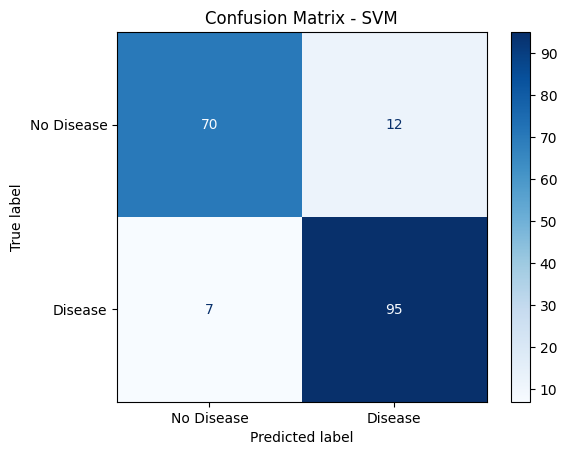

In [30]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.show()


In [31]:
param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.001],
    'classifier__kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(pipelines['SVM'], param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best Recall:", grid_search.best_score_)


Best params: {'classifier__C': 0.1, 'classifier__gamma': 0.001, 'classifier__kernel': 'rbf'}
Best Recall: 1.0


In [32]:
best_params = {'classifier__C': 1, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}

# Update your pipeline with best params
pipelines['SVM'].set_params(**best_params)

# Retrain on full training data
pipelines['SVM'].fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'RestingBP',
                                                   'Cholesterol', 'FastingBS',
                                                   'MaxHR', 'Oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'ChestPainType',
                                                   'RestingECG',
                                                   'ExerciseAngina',
                                                   'ST_Slope'])])),
                ('classifier',
                 SVC(C=1, gamma='auto', probability=True, random_state=42))])

In [33]:
y_pred = pipelines['SVM'].predict(X_test)

print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

Classification Report on Test Set:
              precision    recall  f1-score   support

  No Disease       0.87      0.84      0.86        82
     Disease       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184



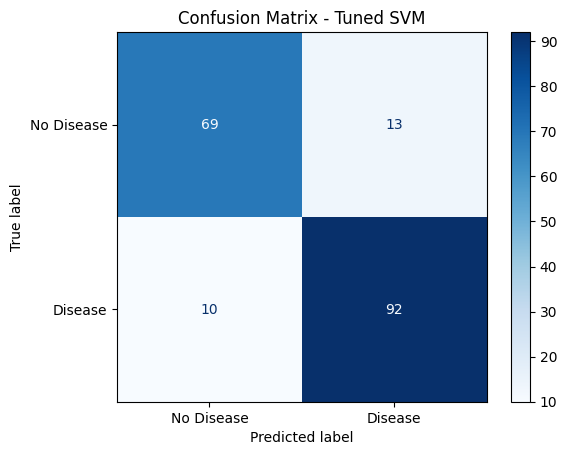

In [34]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Tuned SVM')
plt.show()

# Deep Learning

In [35]:
# Fit the preprocessor on final train set
X_train_final_transformed = preprocessor.fit_transform(X_train_final)

# Transform validation and test sets
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

# Convert to dense arrays if needed (for deep learning)
if hasattr(X_train_final_transformed, "toarray"):
    X_train_final_transformed = X_train_final_transformed.toarray()
    X_val_transformed = X_val_transformed.toarray()
    X_test_transformed = X_test_transformed.toarray()


In [36]:
# Build model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_final_transformed.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['Recall', 'Precision', 'AUC'])

In [38]:
# Train
model.fit(
    X_train_final_transformed, y_train_final,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_transformed, y_val)
)


Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 254ms/step - AUC: 0.7956 - Precision: 0.6624 - Recall: 0.8788 - loss: 0.6086 - val_AUC: 0.8326 - val_Precision: 0.7387 - val_Recall: 0.8039 - val_loss: 0.5558
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.8814 - Precision: 0.8011 - Recall: 0.8789 - loss: 0.5036 - val_AUC: 0.8562 - val_Precision: 0.7456 - val_Recall: 0.8333 - val_loss: 0.4969
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.9111 - Precision: 0.7879 - Recall: 0.9023 - loss: 0.4321 - val_AUC: 0.8702 - val_Precision: 0.7981 - val_Recall: 0.8137 - val_loss: 0.4573
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.9326 - Precision: 0.8536 - Recall: 0.9116 - loss: 0.3655 - val_AUC: 0.8797 - val_Precision: 0.7981 - val_Recall: 0.8137 - val_loss: 0.4359
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.9273 - Precision: 0.8652 - Recall: 0.8864 - loss: 0.3498 - val_AUC: 0.8889 - val_Precision: 0.8400 - val_Recall: 0.8235 - val_loss: 0.4188
Epoch 6/

In [39]:
# Evaluate
results = model.evaluate(X_test_transformed, y_test)
print(f"Test loss, recall, precision, auc: {results}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.9445 - Precision: 0.8834 - Recall: 0.8799 - loss: 0.2964 
Test loss, recall, precision, auc: [0.34415242075920105, 0.8725489974021912, 0.8725489974021912, 0.9264108538627625]


In [40]:
model.save("models/saved_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [41]:
loaded_model = load_model("models/saved_model.h5")


In [42]:
y_pred_prob = loaded_model.predict(X_test_transformed)
# Convert probabilities to binary predictions using a threshold, e.g., 0.5
y_pred = (y_pred_prob > 0.5).astype(int)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


# Model Deployment

In [43]:
app = Flask(__name__)
model = load_model("models/saved_model.h5")

@app.route('/predict', methods=['POST'])
def predict():
    data = request.json  # expects JSON with features
    features = np.array(data['features']).reshape(1, -1)
    prediction_prob = model.predict(features)[0][0]
    prediction = int(prediction_prob > 0.5)
    return jsonify({'prediction': prediction, 'probability': float(prediction_prob)})

if __name__ == '__main__':
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


## Model stacking/blending

In [46]:

# Transform data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# If result is sparse matrix, convert to dense array (some models require dense)
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
    X_test_transformed = X_test_transformed.toarray()

# Now fit the models on transformed data
svm = SVC(probability=True, random_state=42)
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

svm.fit(X_train_transformed, y_train)
rf.fit(X_train_transformed, y_train)
xgb.fit(X_train_transformed, y_train)

# Predict probabilities on test set
svm_probs = svm.predict_proba(X_test_transformed)[:, 1]
rf_probs = rf.predict_proba(X_test_transformed)[:, 1]
xgb_probs = xgb.predict_proba(X_test_transformed)[:, 1]

# Blend predictions
blended_probs = (svm_probs + rf_probs + xgb_probs) / 3
threshold = 0.5
blended_preds = (blended_probs >= threshold).astype(int)

from sklearn.metrics import classification_report, accuracy_score
print("Blended Model Performance:")
print(classification_report(y_test, blended_preds))
print(f"Accuracy: {accuracy_score(y_test, blended_preds):.3f}")


Blended Model Performance:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87        82
           1       0.89      0.90      0.90       102

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184

Accuracy: 0.886


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:12:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [47]:
pip freeze > requirements.txt